# Titanic — Machine Learning from Disaster

Predicting which passengers survived the Titanic sinking, from the classic [Kaggle competition](https://www.kaggle.com/c/titanic).

**Workflow:**
1. Load & inspect the data
2. Exploratory data analysis (EDA) — find the signals
3. Handle missing values & engineer features
4. Compare three models with cross-validation
5. Train the best model and generate a submission


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Fixed categorical palette (assigned by entity, never cycled)
PAL = {"died": "#9498a0", "survived": "#4269d0", "female": "#efb118", "male": "#4269d0"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")
print(train.shape, test.shape)
train.head()

(891, 12) (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 1. Data overview

Each row is a passenger. `Survived` is the target (1 = survived). Key columns: `Pclass` (ticket class, a proxy for wealth), `Sex`, `Age`, `SibSp`/`Parch` (siblings-spouses / parents-children aboard), `Fare`, `Embarked` (port: C = Cherbourg, Q = Queenstown, S = Southampton).

First question for any dataset: **what's missing?**

In [2]:
missing = pd.DataFrame({
    "train_missing": train.isnull().sum(),
    "train_pct": (train.isnull().mean() * 100).round(1),
    "test_missing": test.isnull().sum(),
})
missing[missing.train_missing + missing.test_missing.fillna(0) > 0]

,train_missing,train_pct,test_missing
Age,177,19.9,86.0
Cabin,687,77.1,327.0
Embarked,2,0.2,0.0
Fare,0,0.0,1.0


**Takeaways:** `Cabin` is ~77% missing — too sparse to use directly, but *whether* a cabin was recorded may itself carry signal (recorded cabins skew 1st class). `Age` is ~20% missing and worth imputing carefully. `Embarked` (2 rows) and `Fare` (1 test row) are trivial to fill.

## 2. Exploratory analysis

The two strongest, most famous signals: **sex** and **class**.

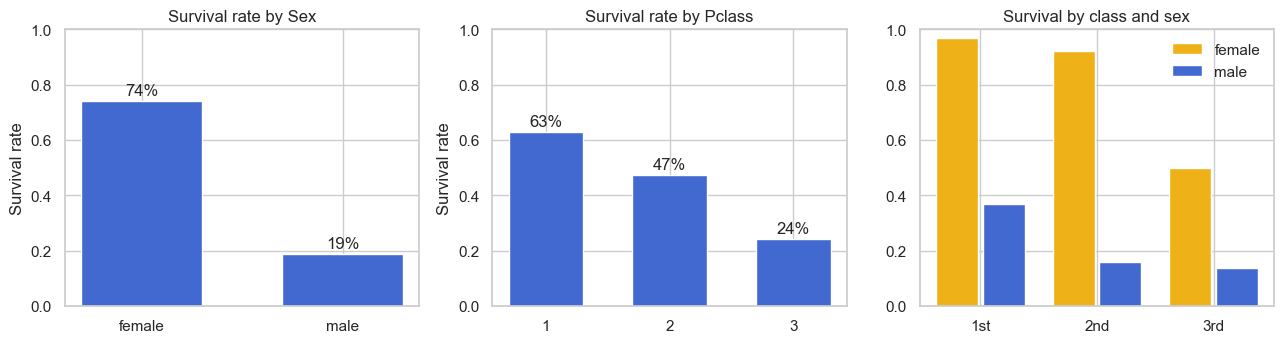

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))

for ax, col in zip(axes[:2], ["Sex", "Pclass"]):
    rates = train.groupby(col)["Survived"].mean()
    bars = ax.bar(rates.index.astype(str), rates.values, color="#4269d0", width=0.6)
    ax.bar_label(bars, fmt="{:.0%}", padding=2)
    ax.set_ylim(0, 1)
    ax.set_title(f"Survival rate by {col}")
    ax.set_ylabel("Survival rate")

# Interaction: sex x class
rates = train.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
x = np.arange(3)
axes[2].bar(x - 0.2, rates["female"], 0.36, label="female", color=PAL["female"])
axes[2].bar(x + 0.2, rates["male"], 0.36, label="male", color=PAL["male"])
axes[2].set_xticks(x, ["1st", "2nd", "3rd"])
axes[2].set_ylim(0, 1)
axes[2].set_title("Survival by class and sex")
axes[2].legend(frameon=False)
plt.tight_layout()
plt.show()

Women in 1st/2nd class survived at ~95%; men in 2nd/3rd class at under 20%. The interaction matters: class barely changes male survival between 2nd and 3rd, but it's decisive for women in 3rd class.

Next: **age** — was "women and children first" also true for children?

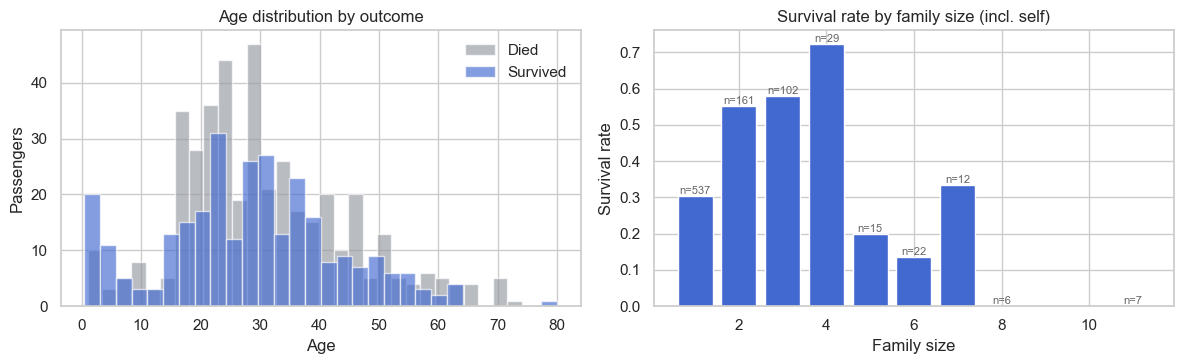

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))

for label, color, key in [("Died", PAL["died"], 0), ("Survived", PAL["survived"], 1)]:
    axes[0].hist(train.loc[train.Survived == key, "Age"].dropna(), bins=30,
                 alpha=0.65, label=label, color=color)
axes[0].set_title("Age distribution by outcome")
axes[0].set_xlabel("Age"); axes[0].set_ylabel("Passengers")
axes[0].legend(frameon=False)

train["FamilySize"] = train.SibSp + train.Parch + 1
fam = train.groupby("FamilySize")["Survived"].agg(["mean", "count"])
bars = axes[1].bar(fam.index, fam["mean"], color="#4269d0")
axes[1].set_title("Survival rate by family size (incl. self)")
axes[1].set_xlabel("Family size"); axes[1].set_ylabel("Survival rate")
for i, (idx, row) in enumerate(fam.iterrows()):
    axes[1].annotate(f"n={row['count']:.0f}", (idx, row['mean']), ha="center",
                     va="bottom", fontsize=8, color="#666")
plt.tight_layout()
plt.show()

Two findings worth engineering features from:
- **Children under ~10 survived disproportionately** (the bump on the left of the survived distribution). Age matters non-linearly.
- **Family size has a sweet spot**: solo travelers and large families (5+) fared worse than small families of 2–4.

## 3. Feature engineering

Ideas, each grounded in the EDA:
- **Title** extracted from `Name` ("Mr", "Mrs", "Miss", "Master", rare titles). "Master" = young boy, so titles also help impute missing ages more accurately than a global median.
- **FamilySize** and **IsAlone**.
- **HasCabin** — whether a cabin was recorded.
- Impute `Age` with the median *per title*, `Embarked` with the mode, `Fare` with the class median.

In [5]:
def engineer(df):
    df = df.copy()
    df["Title"] = df.Name.str.extract(r",\s*([^.]+)\.")[0].str.strip()
    df["Title"] = df.Title.replace(
        {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    common = ["Mr", "Mrs", "Miss", "Master"]
    df["Title"] = df.Title.where(df.Title.isin(common), "Rare")
    df["FamilySize"] = df.SibSp + df.Parch + 1
    df["IsAlone"] = (df.FamilySize == 1).astype(int)
    df["HasCabin"] = df.Cabin.notna().astype(int)
    return df

train_fe = engineer(train)
test_fe = engineer(test)

# Impute Age by title median (computed on train only, to avoid leakage)
age_by_title = train_fe.groupby("Title")["Age"].median()
for df in (train_fe, test_fe):
    df["Age"] = df.Age.fillna(df.Title.map(age_by_title))
    df["Embarked"] = df.Embarked.fillna(train_fe.Embarked.mode()[0])

fare_by_class = train_fe.groupby("Pclass")["Fare"].median()
test_fe["Fare"] = test_fe.Fare.fillna(test_fe.Pclass.map(fare_by_class))

train_fe.groupby("Title")["Survived"].agg(["mean", "count"]).round(3)

,mean,count
Title,,
Master,0.575,40
Miss,0.703,185
Mr,0.157,517
Mrs,0.794,126
Rare,0.348,23


Titles alone separate outcomes strongly — "Mrs"/"Miss" high, "Mr" very low, "Master" (boys) well above adult men. This confirms the feature is worth keeping.

## 4. Model comparison

We compare three models with **5-fold stratified cross-validation** on identical features:
- **Logistic regression** — linear baseline, interpretable
- **Random forest** — bagged trees, captures interactions
- **Gradient boosting** — sequential trees, usually strongest on tabular data

Categorical features are one-hot encoded; numeric ones scaled (only logistic regression needs it, but it doesn't hurt trees).

In [6]:
FEATURES_NUM = ["Age", "Fare", "FamilySize"]
FEATURES_CAT = ["Pclass", "Sex", "Embarked", "Title", "IsAlone", "HasCabin"]

X = train_fe[FEATURES_NUM + FEATURES_CAT]
y = train_fe["Survived"]

pre = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

models = {
    "Logistic regression": LogisticRegression(max_iter=1000),
    "Random forest": RandomForestClassifier(
        n_estimators=400, min_samples_leaf=3, random_state=42),
    "Gradient boosting": GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
for name, model in models.items():
    pipe = Pipeline([("pre", pre), ("model", model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    results[name] = scores
    print(f"{name:22s} {scores.mean():.4f} ± {scores.std():.4f}")

Logistic regression    0.8361 ± 0.0111


Random forest          0.8350 ± 0.0099


Gradient boosting      0.8440 ± 0.0177


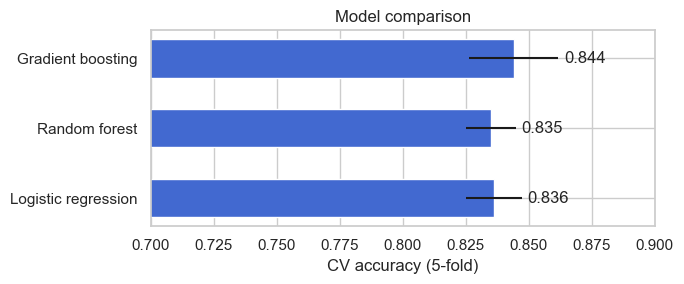

In [7]:
fig, ax = plt.subplots(figsize=(7, 3))
names = list(results)
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]
bars = ax.barh(names, means, xerr=stds, color="#4269d0", height=0.55)
ax.bar_label(bars, fmt="{:.3f}", padding=4)
ax.set_xlim(0.7, 0.9)
ax.set_xlabel("CV accuracy (5-fold)")
ax.set_title("Model comparison")
plt.tight_layout()
plt.show()

## 5. Final model & submission

Train the best model on all of the training data and predict the test set.

In [8]:
best_name = max(results, key=lambda n: results[n].mean())
print("Best model:", best_name)

final = Pipeline([("pre", pre), ("model", models[best_name])])
final.fit(X, y)

X_test = test_fe[FEATURES_NUM + FEATURES_CAT]
preds = final.predict(X_test)

submission = pd.DataFrame({"PassengerId": test_fe.PassengerId, "Survived": preds})
submission.to_csv("submission.csv", index=False)
print(f"submission.csv written — predicted survival rate: {preds.mean():.3f}")
submission.head()

Best model: Gradient boosting


submission.csv written — predicted survival rate: 0.352


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


## Conclusions

- **Sex, class, and title** dominate: women and children in 1st/2nd class mostly survived; adult men in 3rd class mostly did not.
- **Feature engineering** (titles, family size, cabin-recorded flag, title-based age imputation) is where most of the gain over a naive model comes from.
- Cross-validated accuracy of ~0.83 typically lands around **0.77–0.79 on the public leaderboard** (the leaderboard test set is small and slightly different).

**Next steps to try:** hyperparameter tuning (`GridSearchCV`), ticket-group features (passengers sharing tickets often share fates), or an ensemble of all three models. Upload `submission.csv` at https://www.kaggle.com/c/titanic/submit.